# Real GDP (RGDP) ranking CIs

Same procedure as `UNEMP_CI` / `NGDP_CI`, but for the SPF real-GDP panel:
- **Forecasts**: `SPFmicrodata.xlsx`, sheet `RGDP` (RGDP1..RGDP6) — quarterly real-GDP level forecasts.
- **Realizations**: `ROUTPUTQvQd.xlsx` — quarterly RTDSM vintage matrix with prefix `ROUTPUT`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from rankci import (
    rank_ci_stepwise_pairwise,
    rank_ci_marginal_pairwise,
    rank_confidence_intervals_simulation_pairwise,
    rank_ci_stepwise_simulation_pairwise,
    rank_ci_marginal_simulation_pairwise,
    compute_pairwise,
    select_top_forecasters,
    winsorize_panel,
)
from rankci.data.philly import (
    load_spf,
    load_rtdsm,
    compute_errors,
    compute_error_panel,
)
from rankci.data.philly import advance_vintage_col, get_advance_estimate

# Data Loading

In [2]:
df = load_spf("../../data/philly/SPFmicrodata.xlsx", sheet="RGDP")
print(f"SPF RGDP: {df.shape[0]} rows × {df.shape[1]} columns")
print("Columns:", df.columns.tolist())
df.head()

SPF RGDP: 9145 rows × 14 columns
Columns: ['YEAR', 'QUARTER', 'ID', 'INDUSTRY', 'RGDP1', 'RGDP2', 'RGDP3', 'RGDP4', 'RGDP5', 'RGDP6', 'RGDPA', 'RGDPB', 'RGDPC', 'RGDPD']


/Users/Parimah/anaconda3/lib/python3.11/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,YEAR,QUARTER,ID,INDUSTRY,RGDP1,RGDP2,RGDP3,RGDP4,RGDP5,RGDP6,RGDPA,RGDPB,RGDPC,RGDPD
0,1968,4,1,NaN,713.9344,718.6992,721.7742,725.6000,736.0000,744.4444,NaN,NaN,NaN,NaN
1,1968,4,2,NaN,713.9344,724.3902,733.8710,749.1935,766.4000,772.2222,NaN,NaN,NaN,NaN
2,1968,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968,4,4,NaN,713.9344,719.5122,718.5484,721.6000,729.3651,737.7953,NaN,NaN,NaN,NaN
4,1968,4,5,NaN,713.9344,721.7742,730.4000,742.0635,746.0317,763.7795,NaN,NaN,NaN,NaN


In [3]:
routput = load_rtdsm("../../data/philly/ROUTPUTQvQd.xlsx", prefix="ROUTPUT", freq="quarterly")
print(f"RTDSM (ROUTPUT): {routput.shape[0]} quarters × {routput.shape[1]} vintages")
routput.head()

RTDSM (ROUTPUT): 317 quarters × 243 vintages


ROUTPUT65Q4  ROUTPUT66Q1  ROUTPUT66Q2  ROUTPUT66Q3  ROUTPUT66Q4  \
YEAR QUARTER                                                                    
1947 1              306.4        306.4        306.4        306.4        306.4   
     2              309.0        309.0        309.0        309.0        309.0   
     3              309.6        309.6        309.6        309.6        309.6   
     4              314.5        314.5        314.5        314.5        314.5   
1948 1              317.1        317.1        317.1        317.1        317.1   

              ROUTPUT67Q1  ROUTPUT67Q2  ROUTPUT67Q3  ROUTPUT67Q4  ROUTPUT68Q1  \
YEAR QUARTER                                                                    
1947 1              306.4        306.4        306.4        306.4        306.4   
     2              309.0        309.0        309.0        309.0        309.0   
     3              309.6        309.6        309.6        309.6        309.6   
     4              314.5        314.5        314.5        314.5        314.5   
1948 1              317.1        317.1        317.1        317.1        317.1   

              ...  ROUTPUT24Q1  ROUTPUT24Q2  ROUTPUT24Q3  ROUTPUT24Q4  \
YEAR QUARTER  ...                                                       
1947 1        ...       2182.7       2182.7       2182.7       2182.7   
     2        ...       2176.9       2176.9       2176.9       2176.9   
     3        ...       2172.4       2172.4       2172.4       2172.4   
     4        ...       2206.5       2206.5       2206.5       2206.5   
1948 1        ...       2239.7       2239.7       2239.7       2239.7   

              ROUTPUT25Q1  ROUTPUT25Q2  ROUTPUT25Q3  ROUTPUT25Q4  ROUTPUT26Q1  \
YEAR QUARTER                                                                    
1947 1             2182.7       2182.7       2182.7       2182.7       2182.7   
     2             2176.9       2176.9       2176.9       2176.9       2176.9   
     3             2172.4       2172.4       2172.4       2172.4       2172.4   
     4             2206.5       2206.5       2206.5       2206.5       2206.5   
1948 1             2239.7       2239.7       2239.7       2239.7       2239.7   

              ROUTPUT26Q2  
YEAR QUARTER               
1947 1             2182.7  
     2             2176.9  
     3             2172.4  
     4             2206.5  
1948 1             2239.7  

[5 rows x 243 columns]

# Sanity Checks

In [4]:
# Verify advance real-GDP estimates for a few known quarters
test_cases = [(1995, 2), (2008, 4), (2020, 2)]
print(f"{'Target Quarter':<20} {'Vintage Col':<14} {'Real GDP (bn chained $)'}")
print("-" * 60)
for y, q in test_cases:
    col = advance_vintage_col(y, q, prefix="ROUTPUT")
    val = get_advance_estimate(y, q, routput)
    print(f"  {y}:Q{q:<16}  {col:<14}  {val:.1f}")

Target Quarter       Vintage Col    Real GDP (bn chained $)
------------------------------------------------------------
  1995:Q2                 ROUTPUT95Q3     5477.3
  2008:Q4                 ROUTPUT09Q1     11599.4
  2020:Q2                 ROUTPUT20Q3     17205.8


# Forecast Errors

In [5]:
errors_df = compute_errors(df, routput, indicator="RGDP")

print("Error summary by horizon (bn chained $):")
for h in range(1, 7):
    col = f"error_RGDP{h}"
    if col in errors_df.columns:
        print(f"  {col}: mean={errors_df[col].mean():+.2f}, "
              f"std={errors_df[col].std():.2f}, "
              f"nan%={errors_df[col].isna().mean()*100:.1f}%")

errors_df.head()

Error summary by horizon (bn chained $):
  error_RGDP1: mean=+0.12, std=3.00, nan%=5.3%
  error_RGDP2: mean=-49.14, std=275.87, nan%=5.7%
  error_RGDP3: mean=-94.77, std=435.12, nan%=6.1%
  error_RGDP4: mean=-143.42, std=530.77, nan%=6.4%
  error_RGDP5: mean=-191.08, std=609.70, nan%=6.8%
  error_RGDP6: mean=-239.54, std=688.01, nan%=12.1%


,YEAR,QUARTER,ID,INDUSTRY,error_RGDP1,error_RGDP2,error_RGDP3,error_RGDP4,error_RGDP5,error_RGDP6
0,1968,4,1,NaN,1.9344,-0.4008,-1.8258,-1.7000,5.6000,13.9444
1,1968,4,2,NaN,1.9344,5.2902,10.2710,21.8935,36.0000,41.7222
2,1968,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1968,4,4,NaN,1.9344,0.4122,-5.0516,-5.7000,-1.0349,7.2953
4,1968,4,5,NaN,1.9344,2.6742,6.8000,14.7635,15.6317,33.2795


In [6]:
# Squared error panel for RGDP3 (one-quarter-ahead)
X_wide = compute_error_panel(df, routput, indicator="RGDP", horizon=3, metric="squared")
print(f"Panel shape: {X_wide.shape[0]} quarters × {X_wide.shape[1]} forecasters")
X_wide.head()

Panel shape: 225 quarters × 352 forecasters


ID                  1           2          3          4      5          6    \
YEAR QUARTER                                                                  
1968 4         3.333546  105.493441        NaN  25.518663  46.24   3.333546   
1969 1              NaN   36.400709   0.810000  16.810000    NaN   9.610000   
     2         0.229154         NaN  14.726406   1.201435    NaN  92.160000   
     3        13.021272         NaN   4.155482        NaN    NaN  13.021272   
     4        32.214706         NaN   3.564166  63.178652    NaN  32.214706   

ID                  7          8          9          10   ...  598  599  600  \
YEAR QUARTER                                              ...                  
1968 4        57.760000  55.815841  84.640000   3.333546  ...  NaN  NaN  NaN   
1969 1        13.340026  44.423558  12.183590   3.622170  ...  NaN  NaN  NaN   
     2              NaN   3.547572   8.070713  43.664342  ...  NaN  NaN  NaN   
     3              NaN        NaN        NaN  23.859317  ...  NaN  NaN  NaN   
     4        24.188691   0.341290  32.214706        NaN  ...  NaN  NaN  NaN   

ID            601  602  603  604  605  606  607  
YEAR QUARTER                                     
1968 4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
1969 1        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
     2        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
     3        NaN  NaN  NaN  NaN  NaN  NaN  NaN  
     4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  

[5 rows x 352 columns]

# Forecaster Selection

In [7]:
obs_counts = X_wide.notna().sum()
mean_mse = X_wide.mean()

stats = pd.DataFrame({
    "obs_count": obs_counts,
    "mean_mse":  mean_mse,
    "rmse":      np.sqrt(mean_mse),
}).sort_values("obs_count", ascending=False)

print(f"Total forecasters: {len(stats)}")
print(f"Forecasters with >= 20 obs: {(stats['obs_count'] >= 20).sum()}")
print(f"Forecasters with >= 50 obs: {(stats['obs_count'] >= 50).sum()}")
stats.head(20)

Total forecasters: 352
Forecasters with >= 20 obs: 147
Forecasters with >= 50 obs: 53


,obs_count,mean_mse,rmse
ID,,,
65,124,111179.933735,333.436551
426,121,320345.941973,565.991115
433,120,303831.642987,551.209255
421,120,242177.714133,492.115550
84,117,142811.545214,377.904148
428,117,312331.738735,558.866477
411,115,316619.707337,562.689708
40,104,125549.829467,354.330114
510,102,322526.963811,567.914574


In [8]:
N = 8
X_panel = select_top_forecasters(X_wide, N=N, min_obs=20)
print(f"Selected {X_panel.shape[1]} forecasters, {X_panel.shape[0]} quarters")
print(f"Forecaster IDs: {X_panel.columns.tolist()}")

Selected 8 forecasters, 225 quarters
Forecaster IDs: [65, 426, 421, 433, 84, 428, 411, 40]


# Rank Confidence Intervals

In [9]:
X = X_panel.values
population_ids = X_panel.columns.tolist()

out = rank_ci_stepwise_pairwise(X, alpha=0.05, B=5000, seed=42)

results = pd.DataFrame({
    "ID":         population_ids,
    "MSE":        out["theta_hat"].round(4),
    "RMSE":       np.sqrt(out["theta_hat"]).round(4),
    "CI_lower":   out["rank_ci"][:, 0],
    "CI_upper":   out["rank_ci"][:, 1],
}).sort_values("MSE")
results.index = range(1, len(results) + 1)
results.index.name = "Rank"
results

=== Pairwise shared observations ===
  Min: 33, Mean: 73.5, Max: 106
  Pairs with < 20 shared obs: 0

=== Test statistics (delta_hat / se) ===
  Max: 2.7599, Pairs with t > 1.96: 2


,ID,MSE,RMSE,CI_lower,CI_upper
Rank,,,,,
1,65,111179.9337,333.4366,1,8
2,40,125549.8295,354.3301,1,8
3,84,142811.5452,377.9041,1,8
4,421,242177.7141,492.1155,1,8
5,433,303831.6430,551.2093,1,8
6,428,312331.7387,558.8665,1,8
7,411,316619.7073,562.6897,1,8
8,426,320345.9420,565.9911,1,8


# Worst-Quarter Inspection

Time coverage: (1968, 4) to (2025, 1) (225 quarters)

Top 10 quarters with highest average squared error:
YEAR  QUARTER
2023  2          5.062437e+06
2020  1          4.812389e+06
2023  3          4.796147e+06
1985  4          3.627270e+06
      3          3.616343e+06
2013  2          3.567640e+06
      1          3.289428e+06
2009  2          2.843315e+06
      1          2.125483e+06
1995  4          1.474248e+06
dtype: float64


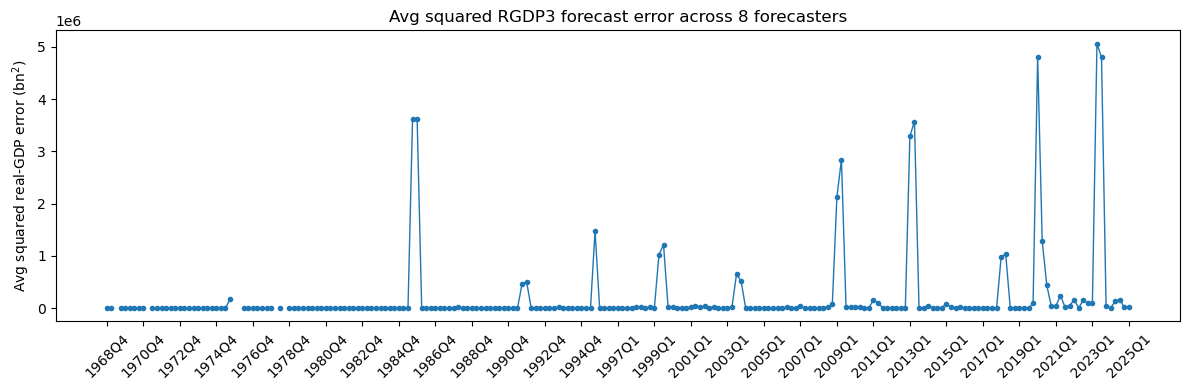

In [10]:
period_mse = X_panel.mean(axis=1)

print(f"Time coverage: {X_panel.index[0]} to {X_panel.index[-1]} ({len(X_panel)} quarters)\n")
print("Top 10 quarters with highest average squared error:")
print(period_mse.nlargest(10))

n = len(X_panel)
plt.figure(figsize=(12, 4))
plt.plot(range(n), period_mse, marker="o", linewidth=1, markersize=3)
plt.xticks(
    ticks=range(0, n, 8),
    labels=[f"{y}Q{q}" for y, q in X_panel.index[::8]],
    rotation=45,
)
plt.ylabel("Avg squared real-GDP error (bn$^2$)")
plt.title(f"Avg squared RGDP3 forecast error across {N} forecasters")
plt.tight_layout()
plt.show()

# Winsorization (variant 2: pairwise differences)

In [11]:
print("=== Winsorize pairwise differences ===")
print(f"{'winsor_pct':<12} {'max_t':<10} {'mean CI width':<16}")
print("-" * 40)
for winsor_pct in [99, 97, 95, 90]:
    delta_w, se_w, _ = compute_pairwise(X, se_method="nw", winsor_pct=winsor_pct)
    t_vals = (delta_w / se_w)[~np.isnan(se_w)]

    out_w = rank_ci_stepwise_pairwise(
        X, alpha=0.05, B=1000, seed=42, winsor_pct=winsor_pct, verbose=False,
    )
    widths = out_w["rank_ci"][:, 1] - out_w["rank_ci"][:, 0]

    print(f"  {winsor_pct:<10} {t_vals.max():<10.3f} {widths.mean():<16.2f}")

=== Winsorize pairwise differences ===
winsor_pct   max_t      mean CI width   
----------------------------------------
  99         2.787      7.00            
  97         2.920      7.00            
  95         4.223      7.00            
  90         4.920      7.00            


# Marginal Rank Confidence Intervals

Per-forecaster CIs that control coverage marginally (no joint family-wise error control).

In [12]:
out_marg = rank_ci_marginal_pairwise(X, alpha=0.1, B=5000, seed=42)

results_marg = pd.DataFrame({
    "ID":       population_ids,
    "MSE":      out_marg["theta_hat"].round(4),
    "RMSE":     np.sqrt(out_marg["theta_hat"]).round(4),
    "cv_j":     out_marg["critical_values"].round(3),
    "CI_lower": out_marg["rank_ci"][:, 0],
    "CI_upper": out_marg["rank_ci"][:, 1],
}).sort_values("MSE")
results_marg.index = range(1, len(results_marg) + 1)
results_marg.index.name = "Rank"
results_marg

,ID,MSE,RMSE,cv_j,CI_lower,CI_upper
Rank,,,,,,
1,65,111179.9337,333.4366,2.524,1,8
2,40,125549.8295,354.3301,3.130,1,8
3,84,142811.5452,377.9041,2.465,1,7
4,421,242177.7141,492.1155,2.768,1,8
5,433,303831.6430,551.2093,2.652,1,8
6,428,312331.7387,558.8665,2.651,1,8
7,411,316619.7073,562.6897,2.709,1,8
8,426,320345.9420,565.9911,2.880,1,8


# Sensitivity to NW bandwidth `L`

Sweep `L ∈ {auto, 1, 2, 4, 8, 20}` for the marginal procedure.

In [13]:
L_values = [None, 1, 2, 4, 8, 20]

ci_by_L = {}
maxt_by_L = {}
for L in L_values:
    delta, se, _ = compute_pairwise(X, se_method="nw", L=L)
    maxt_by_L[L] = float(np.nanmax(delta / se))
    out_L = rank_ci_marginal_pairwise(X, alpha=0.05, B=2000, seed=42, L=L)
    ci_by_L[L] = out_L["rank_ci"]

order = np.argsort(out_marg["theta_hat"])
ordered_ids = [population_ids[i] for i in order]

table_L = pd.DataFrame(
    {
        f"L={L if L is not None else 'auto'}":
            [f"[{ci_by_L[L][i, 0]},{ci_by_L[L][i, 1]}]" for i in order]
        for L in L_values
    },
    index=ordered_ids,
)
table_L.index.name = "ID"

print("max test stat by L:")
for L, t in maxt_by_L.items():
    label = "auto" if L is None else str(L)
    print(f"  L={label:<5}  max_t = {t:.3f}")
print()
table_L

max test stat by L:
  L=auto   max_t = 2.760
  L=1      max_t = 2.788
  L=2      max_t = 2.741
  L=4      max_t = 2.824
  L=8      max_t = 3.001
  L=20     max_t = 3.775



,L=auto,L=1,L=2,L=4,L=8,L=20
ID,,,,,,
65,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
40,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
84,"[1,8]","[1,8]","[1,8]","[1,7]","[1,7]","[1,7]"
421,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
433,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
428,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
411,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"
426,"[1,8]","[1,8]","[1,8]","[1,8]","[1,8]","[1,8]"


# MAE-based ranking

In [14]:
N      = 5
alpha  = 0.2
L      = None

# MAE
X_mae_wide  = compute_error_panel(df, routput, indicator="RGDP", horizon=3, metric="absolute")
X_mae_panel = select_top_forecasters(X_mae_wide, N=N, min_obs=20)
X_mae       = X_mae_panel.values
ids_mae     = X_mae_panel.columns.tolist()

out_mae = rank_ci_marginal_pairwise(X_mae, alpha=alpha, B=5000, seed=42, L=L)

# MSE — same forecasters, same alpha/L, but using squared errors
X_mse_wide  = compute_error_panel(df, routput, indicator="RGDP", horizon=3, metric="squared")
X_mse_panel = select_top_forecasters(X_mse_wide, N=N, min_obs=20)
X_mse       = X_mse_panel.values
ids_mse     = X_mse_panel.columns.tolist()

out_mse = rank_ci_marginal_pairwise(X_mse, alpha=alpha, B=5000, seed=42, L=L)

order = np.argsort(out_mae["theta_hat"])

results_compare = pd.DataFrame({
    "ID":       [ids_mae[i] for i in order],
    "MAE":      out_mae["theta_hat"][order].round(3),
    "MSE":      out_mse["theta_hat"][order].round(4),
    "CI_MAE":   [f"[{l},{u}]" for l, u in out_mae["rank_ci"][order]],
    "CI_MSE":   [f"[{l},{u}]" for l, u in out_mse["rank_ci"][order]],
})
results_compare.index = range(1, len(results_compare) + 1)
results_compare.index.name = "MAE_rank"
results_compare

,ID,MAE,MSE,CI_MAE,CI_MSE
MAE_rank,,,,,
1,65,122.252,111179.9337,"[1,5]","[3,5]"
2,84,146.364,142811.5452,"[1,4]","[1,3]"
3,421,236.102,242177.7141,"[1,5]","[1,5]"
4,433,257.618,303831.6430,"[1,5]","[1,5]"
5,426,275.956,320345.9420,"[2,5]","[3,5]"


# τ-best confidence set (Algorithm 3.3)

A forecaster is *included* in the τ-best set iff there is no evidence that — even after exempting any $\tau-1$ others — at least one population outside the exemption is substantially better. We sweep $\tau \in \{1, 2, 3\}$ at $\alpha = 0.2$ and compare Algorithm 3.3 with the naive projection from joint stepwise rank CIs.

In [15]:
from rankci import tau_best_pairwise, tau_best_from_rank_ci

ALPHA_TAU = 0.2
B_TAU     = 5000
SEED_TAU  = 42

X = X_panel.values
population_ids = X_panel.columns.tolist()

# Joint stepwise rank CIs at the same alpha (basis for the naive projection)
out_rank = rank_ci_stepwise_pairwise(
    X, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
)

rows = []
for tau in [1, 2, 3]:
    res = tau_best_pairwise(
        X, tau=tau, alpha=ALPHA_TAU, B=B_TAU, seed=SEED_TAU, verbose=False,
    )
    naive = tau_best_from_rank_ci(out_rank["rank_ci"], tau=tau)
    rows.append({
        "tau":             tau,
        "n_direct":        int(res["n_in_set"]),
        "set_direct":      [population_ids[j] for j, v in enumerate(res["tau_best_set"]) if v],
        "n_naive":         int(naive.sum()),
        "set_naive":       [population_ids[j] for j, v in enumerate(naive) if v],
        "max_test_stat":   round(float(np.nanmax(res["test_stats"])), 3),
    })

tau_sweep = pd.DataFrame(rows).set_index("tau")
print(f"alpha = {ALPHA_TAU}, B = {B_TAU}, p = {len(population_ids)}")
print(f"Forecaster IDs: {population_ids}")
print()
tau_sweep

alpha = 0.2, B = 5000, p = 8
Forecaster IDs: [65, 426, 421, 433, 84, 428, 411, 40]



,n_direct,set_direct,n_naive,set_naive,max_test_stat
tau,,,,,
1,8,"[65, 426, 421, 433, 84, 428, 411, 40]",8,"[65, 426, 421, 433, 84, 428, 411, 40]",2.760
2,8,"[65, 426, 421, 433, 84, 428, 411, 40]",8,"[65, 426, 421, 433, 84, 428, 411, 40]",1.852
3,8,"[65, 426, 421, 433, 84, 428, 411, 40]",8,"[65, 426, 421, 433, 84, 428, 411, 40]",1.551
